In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [4]:
train_data = datasets.ImageFolder(
    "datasets/train",
    transform=train_transform
)

val_data = datasets.ImageFolder(
    "datasets/val",
    transform=test_transform
)

test_data = datasets.ImageFolder(
    "datasets/test",
    transform=test_transform
)

print("Classes:", train_data.classes)
print("Class Mapping:", train_data.class_to_idx)

Classes: ['cancer', 'normal']
Class Mapping: {'cancer': 0, 'normal': 1}


In [5]:
train_loader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False
)

print("Train Images:", len(train_data))
print("Validation Images:", len(val_data))
print("Test Images:", len(test_data))

Train Images: 600
Validation Images: 150
Test Images: 150


In [6]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features,2)
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001,
    weight_decay=1e-4
)

In [8]:
epochs = 30

best_acc = 0
patience = 5
counter = 0

train_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    val_acc = 100 * correct / total

    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss:{avg_loss:.4f} "
        f"Val Accuracy:{val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(
            model.state_dict(),
            "best_pancreatic_model.pth"
        )

    else:
        counter += 1

    if counter >= patience:

        print(
            "Early Stopping Triggered"
        )

        break

print(
    "Best Validation Accuracy:",
    best_acc
)

Epoch [1/30] Loss:0.4489 Val Accuracy:84.67%
Epoch [2/30] Loss:0.1107 Val Accuracy:82.00%
Epoch [3/30] Loss:0.0668 Val Accuracy:64.00%
Epoch [4/30] Loss:0.0728 Val Accuracy:86.67%
Epoch [5/30] Loss:0.0491 Val Accuracy:83.33%
Epoch [6/30] Loss:0.0542 Val Accuracy:98.67%
Epoch [7/30] Loss:0.0240 Val Accuracy:98.67%
Epoch [8/30] Loss:0.0423 Val Accuracy:80.67%
Epoch [9/30] Loss:0.0254 Val Accuracy:94.67%
Epoch [10/30] Loss:0.0187 Val Accuracy:96.00%
Epoch [11/30] Loss:0.0227 Val Accuracy:94.00%
Early Stopping Triggered
Best Validation Accuracy: 98.66666666666667


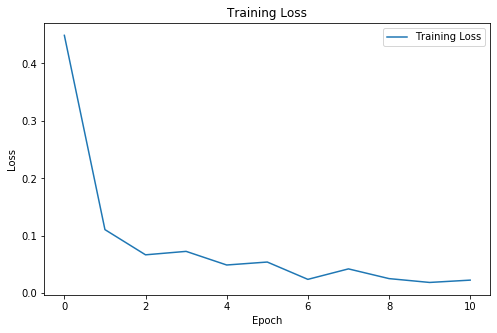

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

In [10]:
model.load_state_dict(
    torch.load(
        "best_pancreatic_model.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [11]:
y_true = []
y_pred = []
y_scores = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predicted.cpu().numpy()
        )

        y_scores.extend(
            probs[:,1]
            .cpu()
            .numpy()
        )

In [12]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    "Accuracy:",
    accuracy*100
)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_data.classes
    )
)

Accuracy: 87.33333333333333
              precision    recall  f1-score   support

      cancer       0.94      0.80      0.86        75
      normal       0.83      0.95      0.88        75

    accuracy                           0.87       150
   macro avg       0.88      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150



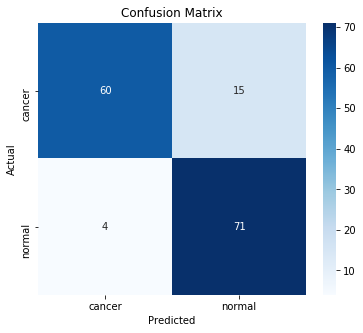

In [13]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_data.classes,
    yticklabels=test_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

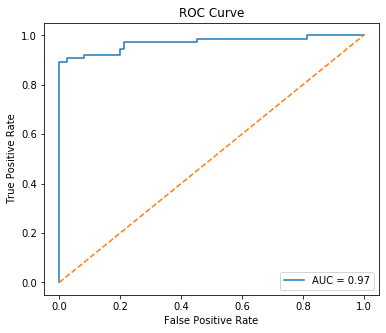

AUC Score: 0.9706666666666668


In [14]:
fpr, tpr, _ = roc_curve(
    y_true,
    y_scores
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title("ROC Curve")

plt.legend()

plt.show()

print(
    "AUC Score:",
    roc_auc
)